In [162]:
import cv2
import sys
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from retinaface.detector import RetinafaceDetector

In [163]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [164]:
val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [165]:
face_detector = RetinafaceDetector(net='mnet', type='cuda' if torch.cuda.is_available() else 'cpu')

In [166]:
########### concatenation
# concatenation of output from simaese network
class SiameseNetwork(nn.Module):

    def __init__(self, hidden_layer_neurons = 256 ):
        super(SiameseNetwork, self).__init__()
        model_path = "./pretrained_model/mobilefacenet_scripted.pt"
    
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # sets device for model and PyTorch tensors
        
        self.backbone = torch.jit.load(model_path, map_location=self.device)
        for param in self.backbone.parameters():
            param.requires_grad = False
#         self.bn = nn.BatchNorm1d(num_features=128) # 128 because the output of mobilefacenet is 128 dimensional
#         self.ln = nn.LayerNorm(128) # 128 because the output of mobilefacenet is 128 dimensional
        self.fc_classifier = nn.Sequential(
            nn.Linear(256, hidden_layer_neurons), # 1 hidden layer with 32 neurons
            nn.ReLU(),
#             nn.Linear(hidden_layer_neurons, hidden_layer_neurons//2), # 1 hidden layer with 32 neurons
#             nn.ReLU(),
#             nn.Dropout(p=0.5),
            nn.Linear(hidden_layer_neurons, 1),
            nn.Sigmoid()
        )
        self.mode = 'train' 
        

    def forward_once(self, x):
        output = self.backbone(x)
#         output = self.ln(output)
#         output = self.bn(output)
        return output
    
    def forward_train(self, data : dict):
        input1 = data['sample'].to(self.device)
        input2 = data['frame'].to(self.device)
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        output = torch.cat((output1, output2), 1)
        return output
    
    def forward_test(self, image):
        image = image.to(self.device)
        output2 = self.forward_once(image)
        output = torch.cat((self.sample, output2), 1)
        return output

    
    def forward(self, data):
        if self.mode == 'test':
            output = self.forward_test(data)
        else:
            output= self.forward_train(data)
        
        output = self.fc_classifier(output)
        return output
    
    def init(self, images): # initialization of sample images
        images = images.to(self.device)
        samples = self.forward_once(images)
        if samples.shape[0] == 1:
            self.sample = samples
        else:
            self.sample = samples.mean(axis=0).unsqueeze(0)

In [167]:
model = SiameseNetwork().to(device)

checkpoint_path = 'classifier_model/checkpoint.tar'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['weights'])

model.eval()
print("Model Ready")

Model Ready


In [168]:
def auto_crop(img_path, max_size=640):
 
    img_raw = cv2.imread(img_path)
    
    if img_raw is None:
        print(f"❌ Error: Gambar {img_path} gak ketemu atau rusak!")
        return None

    h, w = img_raw.shape[:2]
    
    # 1. JURUS KECILIN GAMBAR: Biar muka raksasa bisa masuk jaring AI
    scale = 1.0
    if max(h, w) > max_size:
        scale = max_size / max(h, w)
        # Resize khusus buat dicarikan wajahnya doang
        img_det = cv2.resize(img_raw, (int(w * scale), int(h * scale)))
    else:
        img_det = img_raw.copy()

    dets, landms = face_detector.detect_faces(img_det)

    if len(dets) == 0:
        print(f"⚠️ Waduh, nggak ada wajah yang kedeteksi di {img_path}!")
        return None

    print(f"🔍 Ditemukan {len(dets)} kandidat wajah. Skor keyakinan tertinggi: {dets[0][4]*100:.2f}%")

    box = dets[0]
    score = box[4]
    
    if score < 0.50:  
        print(f"⚠️ Gambar di-skip. Cuma yakin {score*100:.1f}%.")
        return None

    x1 = box[0] / scale
    y1 = box[1] / scale
    x2 = box[2] / scale
    y2 = box[3] / scale

    # --- JURUS MARGIN PROPORSIONAL & KOTAK SEMPURNA ---
    box_w = x2 - x1
    box_h = y2 - y1
    
    # Cari sisi terpanjang biar potongannya selalu KOTAK (Square)
    side_length = max(box_w, box_h)
    
    # Tambah margin 40% dari ukuran wajah (Biar rambut & dagu masuk)
    margin = int(side_length * 0.4)
    final_side = side_length + margin
    
    # Cari titik tengah wajah (Center of Mass)
    center_x = x1 + (box_w / 2)
    center_y = y1 + (box_h / 2)
    
    # Hitung ulang koordinat potongan kotak yang baru
    x1_new = max(0, int(center_x - (final_side / 2)))
    y1_new = max(0, int(center_y - (final_side / 2)))
    x2_new = min(w, int(center_x + (final_side / 2)))
    y2_new = min(h, int(center_y + (final_side / 2)))

    # Eksekusi Potong di gambar ASLI (Resolusi tinggi)
    cropped_bgr = img_raw[y1_new:y2_new, x1_new:x2_new]
    cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)
    
    return Image.fromarray(cropped_rgb)

In [169]:
def face_match(img_path_1, img_path_2, threshold=0.5):
    
    img1 = auto_crop(img_path_1)
    img2 = auto_crop(img_path_2)

    if img1 is None or img2 is None:
        print("Proses dihentikan karena wajah tidak lengkap.")
        return
    
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(img1)
    ax[0].set_title("Foto 1")
    ax[0].axis('off')
    ax[1].imshow(img2)
    ax[1].set_title("Foto 2")
    ax[1].axis('off')
    plt.show()

    tensor1 = val_transform(img1).unsqueeze(0).to(device)
    tensor2 = val_transform(img2).unsqueeze(0).to(device)
    
    data = {'sample': tensor1, 'frame': tensor2}
    
    with torch.no_grad():
        output_prob = model(data)
        
    score = output_prob.item()
    
    print("-" * 30)
    print(f"Skor Kecocokan : {score * 100:.2f}%")
    
    if score >= threshold:
        print("Kesimpulan     : ✅ INI ORANG YANG SAMA!")
    else:
        print("Kesimpulan     : ❌ INI ORANG YANG BERBEDA!")
    print("-" * 30)



🔍 Ditemukan 1 kandidat wajah. Skor keyakinan tertinggi: 99.99%
🔍 Ditemukan 1 kandidat wajah. Skor keyakinan tertinggi: 99.99%


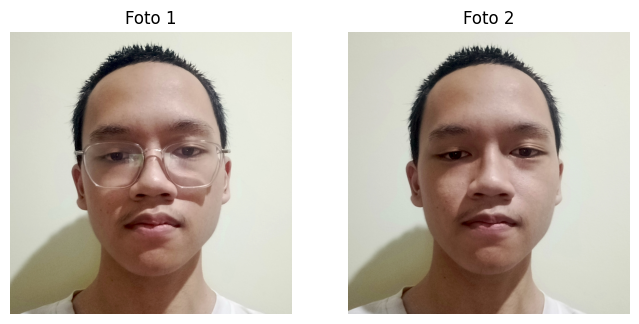

------------------------------
Skor Kecocokan : 67.72%
Kesimpulan     : ✅ INI ORANG YANG SAMA!
------------------------------


In [170]:
# --- CARA PAKAINYA ---
# Siapkan 2 foto (misal foto Ben Affleck dua-duanya, atau foto Ben dan Elton)
foto_tes_1 = "./dataset/inference_face_set/Arjuna1.jpg" 
foto_tes_2 = "./dataset/inference_face_set/Arjuna2.jpg"

# Eksekusi!
face_match(foto_tes_1, foto_tes_2)